In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import scienceplots
import colormaps as cmaps

from nanonets import Simulation
from nanonets.utils import load_simulation_results, get_net_currents, create_weighted_undirected_graph, display_net_flow_graph

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 320
N_E         = 8
L_VALS      = [3,5,7,9,11,13,15]
V_INPUT     = np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS, endpoint=False)
V_I_PLOT    = 1000*V_INPUT
# PATH        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/network/"
PATH        = "/home/j/j_mens07/bagheera/data/1_funding_period/iv_curves/network/"

### IV-Curves at Cg=0.28

In [4]:
data = {L : pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8.csv").sort_values(by='E0',ignore_index=True) for L in L_VALS}

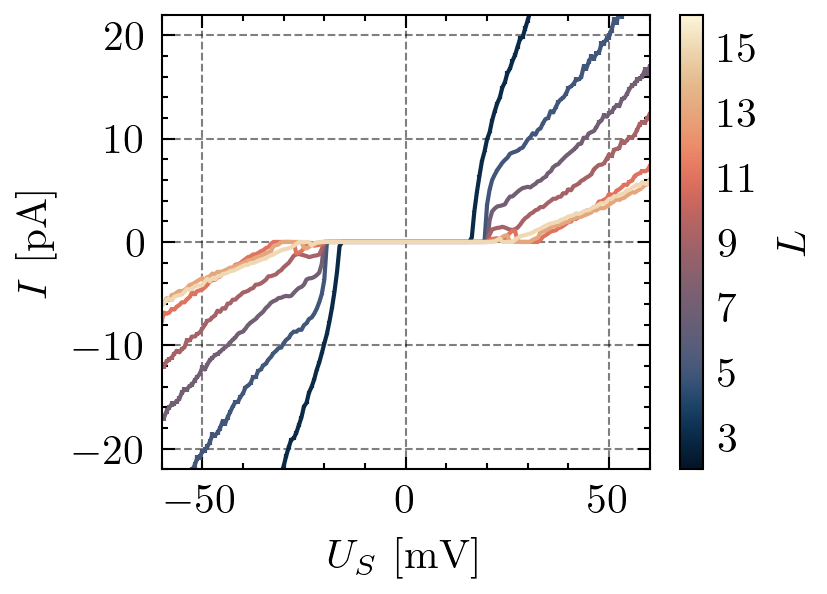

In [8]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=L_VALS[0]-1,vmax=L_VALS[-1]+1)
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALS):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmaps.lipari(norm(N)))
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-60,60)
_   = ax.set_ylim(-22,22)

sm      = plt.cm.ScalarMappable(cmap=cmaps.lipari, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$L$")
_       = cbar.set_ticks(L_VALS)

fig.savefig(f"plots/svg/network_iv_curves.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves.png", transparent=False)

### Potential Landscape

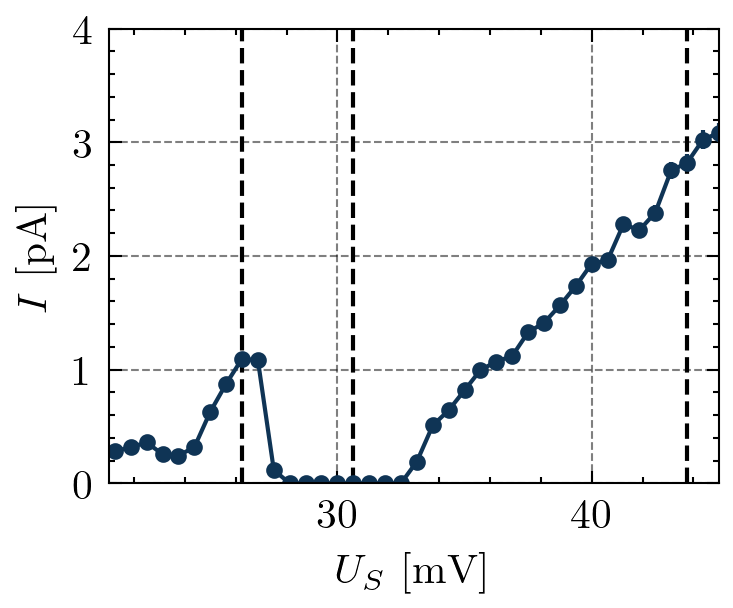

In [9]:
N       = 11
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
df      = data[N].copy().sort_values(by='E0')
x       = df['E0'].values*1000
y       = df['Observable'].values*1e-6
y_e     = df['Error'].values*1e-6
_       = ax.errorbar(x, y, y_e, marker='.', color=cmaps.lipari(0.1))
_       = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_       = ax.set_ylabel("$I~[\mathrm{pA}]$")
_       = ax.set_xlim(21,45)
_       = ax.set_ylim(0,4)
for j in [202, 209 , 230]:
    _   = plt.axvline(x[j], color='black', lw=1, ls='--')

fig.savefig(f"plots/svg/11_11_net_IV_state_sample.svg", transparent=True)
fig.savefig(f"plots/pdf/11_11_net_IV_state_sample.pdf", transparent=False)
fig.savefig(f"plots/png/11_11_net_IV_state_sample.png", transparent=False)

In [10]:
state = {L : pd.read_csv(f"{PATH}mean_state_Nx={L}_Ny={L}_Ne=8.csv") for L in L_VALS}

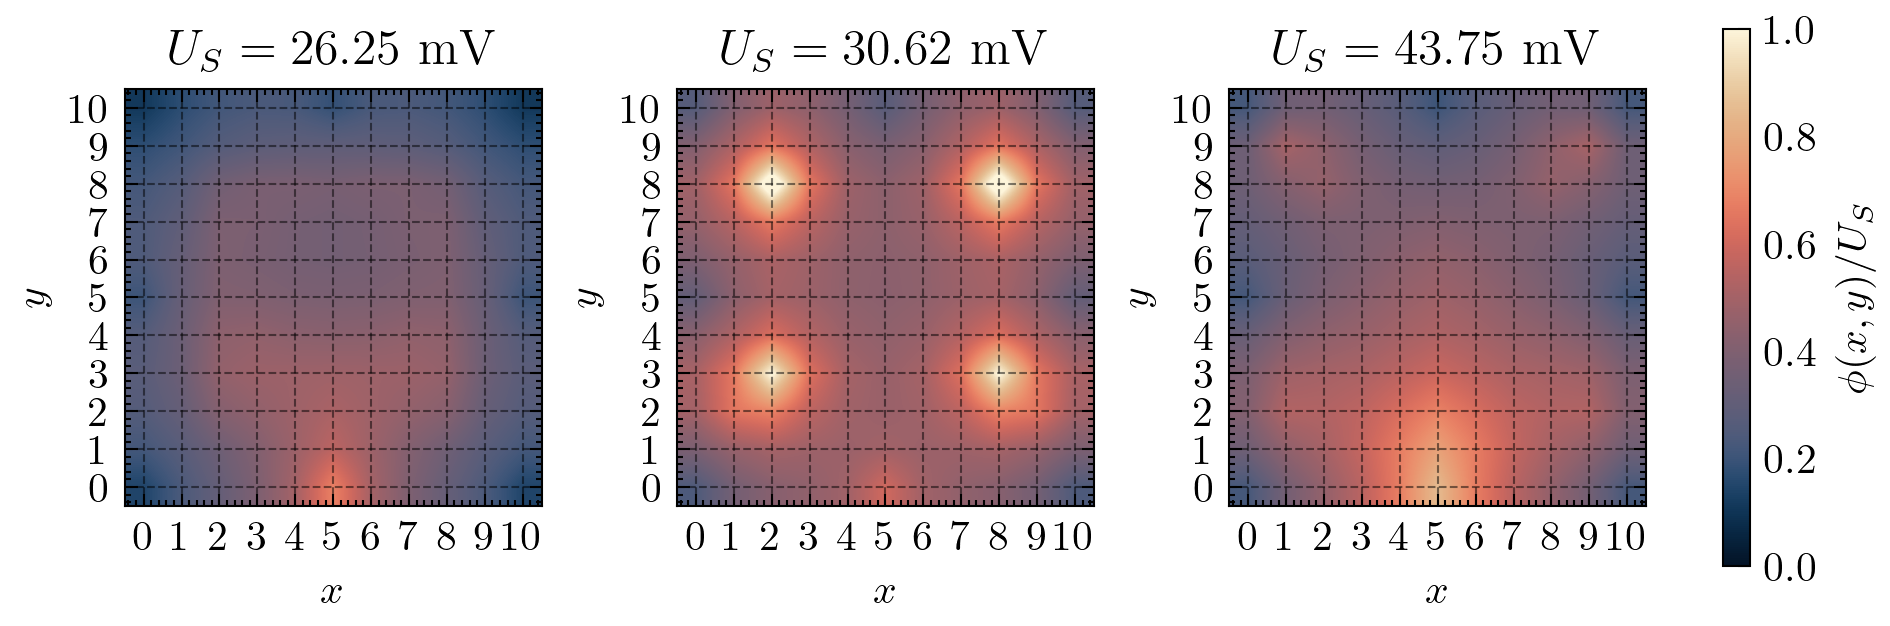

In [13]:
N           = 11
fig, axs    = plt.subplots(1, 3, dpi=300, layout='constrained')
_           = fig.set_figwidth(fig.get_figwidth()*1.8)
_           = fig.set_figheight(fig.get_figheight()*0.8)

j_vals       = [202, 209, 230]
heatmap_axes = [axs[0], axs[1], axs[2]]

for i, j in enumerate(j_vals):
    ax = heatmap_axes[i]
    
    df_state = state[N].sort_values(by='0').reset_index(drop=True)
    U_v = df_state.iloc[j, 0]
    arr = df_state.iloc[j, 8:].values.reshape(N, N) / U_v
    im = ax.imshow(arr, origin='lower', cmap=cmaps.lipari, vmin=0., vmax=1, interpolation='bilinear')
    ax.set_title(f"$U_S = {U_v*1000:.2f}~\mathrm{{mV}}$")
    
    # Tick formatting
    ax.set_xticks(np.arange(N))
    ax.set_yticks(np.arange(N))
    # ax.set_xticklabels()
    # ax.set_yticklabels("")

    # if i == 0:
    ax.set_ylabel("$y$")
    ax.set_xlabel("$x$")

# --- Colorbar ---
cb = fig.colorbar(im, ax=axs, label='$\phi(x,y) / U_S$')

fig.savefig(f"plots/svg/11_11_net_state_sample.svg", transparent=True)
fig.savefig(f"plots/pdf/11_11_net_state_sample.pdf", transparent=False)
fig.savefig(f"plots/png/11_11_net_state_sample.png", transparent=False)

### Network Currents

In [14]:
data_ref     = {L : pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8.csv") for L in L_VALS}
net_currents = {L : pd.read_csv(f"{PATH}net_currents_Nx={L}_Ny={L}_Ne=8.csv") for L in L_VALS}

In [15]:
L           = 11
topo        = {"Nx": L,"Ny": L, "e_pos": [[(L-1)//2, 0],[0, 0],[L-1, 0],
                [0, (L-1)//2],[L-1, (L-1)//2],[0, L-1],
                [L-1, L-1],[(L-1)//2, L-1]],
            "electrode_type": ['constant']*8}
sim_class   = Simulation(topo)
pos         = sim_class.get_positions()
pos         = {(key+8 if key >= 0 else (abs(key)-1)) : (val) for key, val in pos.items()}
j_vals      = [202, 209 , 230]

In [32]:
s_tmp.max()

np.float64(32.72772861026135)

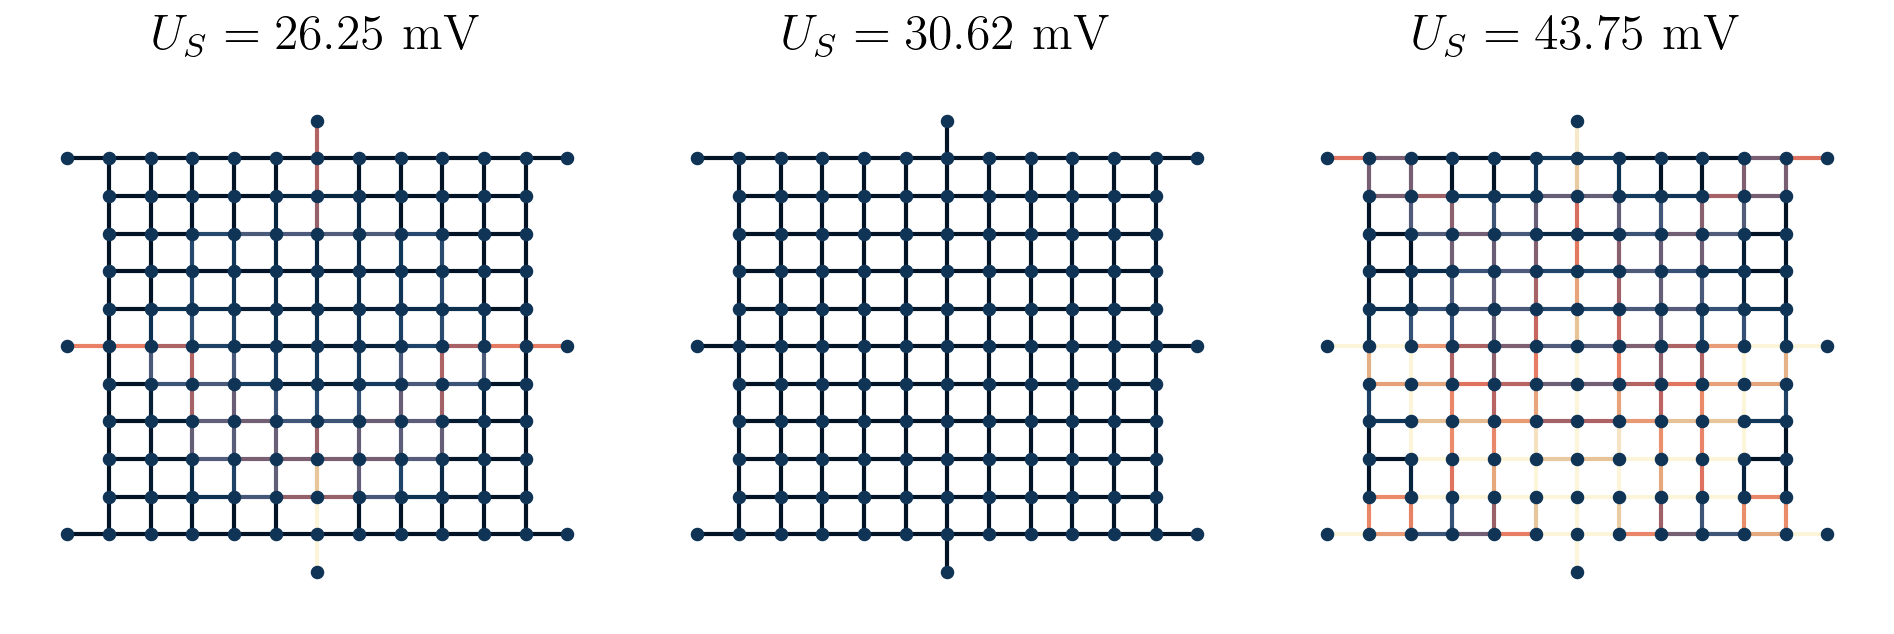

In [38]:
fig     = plt.figure(dpi=300, layout='constrained')
axs     = []
_       = fig.set_figwidth(fig.get_figwidth()*1.8)
_       = fig.set_figheight(fig.get_figheight()*0.8)
cmap    = plt.get_cmap('cividis')
vmax    = 3e0
norm    = mcolors.LogNorm(vmin=1e-3,vmax=vmax)

for i, j in enumerate(j_vals):
    ax          = fig.add_subplot(1,3,i+1)
    idx_sorted  = data_ref[L].sort_values(by='E0').index
    df_tmp      = net_currents[L].iloc[idx_sorted,:].reset_index(drop=True).iloc[j,:]
    s_tmp       = np.sqrt((get_net_currents(pd.DataFrame([df_tmp]))**2).sum())*1e-6
    G           = create_weighted_undirected_graph(s_tmp)
    ax          = display_net_flow_graph(G, pos=pos, log_scale=True, font_size=None, ax=ax,
                                         vmin=1e-3, vmax=vmax, cmap=cmaps.lipari, node_size=5, node_color=cmaps.lipari(0.1))
    U_v         = df_state.iloc[j, 0]
    _           = ax.set_title(f"$U_S = {U_v*1000:.2f}~\mathrm{{mV}}$")
    axs.append(ax)

    
# sm      = plt.cm.ScalarMappable(cmap=cmaps.lipari, norm=norm)
# cbar    = fig.colorbar(sm, ax=axs)
# _       = cbar.set_label("$I_{ij}~[\mathrm{pA}]$")

fig.savefig(f"plots/svg/11_11_net_currents_sample.svg", transparent=True)
fig.savefig(f"plots/pdf/11_11_net_currents_sample.pdf", transparent=False)
fig.savefig(f"plots/png/11_11_net_currents_sample.png", transparent=False)

### Charging Energy Thresholds

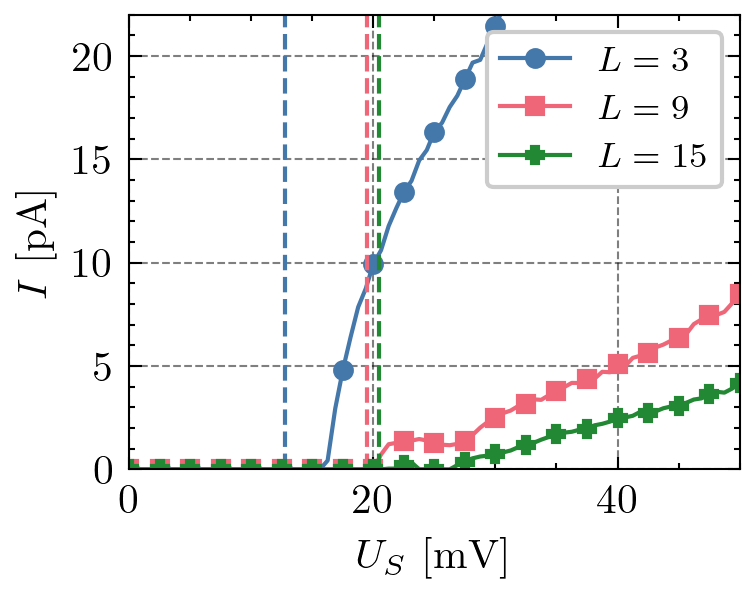

In [33]:
V_TH    = {L+3 : val for L, val in enumerate(np.load(
    "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/charging_energies/edge_mean_0.28.npy"))}

fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
marker  = ['o','s','P']

for i, N in enumerate([3,9,15]):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    pp  = ax.plot(x, y, label=f'$L = {N}$', marker=marker[i], ms=4, markevery=4)
    _   = plt.axvline(V_TH[N], color=pp[0].get_color(), ls='--', lw=1)

_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(0,50)
_   = ax.set_ylim(0,22)
_   = ax.legend(fontsize='small')

fig.savefig(f"plots/svg/network_iv_curves_and_vth.svg", transparent=True)
fig.savefig(f"plots/pdf/network_iv_curves_and_vth.pdf", transparent=False)
fig.savefig(f"plots/png/network_iv_curves_and_vth.png", transparent=False)